---
date: "2026-06-27"
date-modified: last-modified
format:
  html:
    toc: true
---

# The Uniform Distribution and Universality

The Uniform distribution models a completely random choice within a continuous interval $(a, b)$. It represents the state of maximum uncertainty over a bounded continuous space, as probability is strictly proportional to length.

## 1. Definition, PDF, and CDF

**Definition:** A continuous [random variable](random-variables.ipynb) $X$ follows the Uniform distribution on the interval $(a, b)$, denoted $X \sim Unif(a, b)$, if its [Probability Density Function (PDF)](probability-density-function.ipynb) is constant over that interval.

**PDF:**
Because the area under the PDF must perfectly equal 1, the height of the constant function over a width of $(b-a)$ must be its reciprocal:
$$f(x) = \begin{cases} \frac{1}{b-a} & \text{if } a < x < b \\ 0 & \text{otherwise} \end{cases}$$

**CDF:**
By integrating the PDF from $a$ to $x$, we obtain the Cumulative Distribution Function (CDF), which increases linearly from 0 to 1:
$$F(x) = \begin{cases} 0 & \text{if } x \le a \\ \frac{x-a}{b-a} & \text{if } a < x < b \\ 1 & \text{if } x \ge b \end{cases}$$

## 2. Expected Value and Variance

**Theorem:** If $X \sim Unif(a, b)$, then $E[X] = \frac{a+b}{2}$ and $Var(X) = \frac{(b-a)^2}{12}$.

**Proof of Expected Value:**
$$E[X] = \int_{a}^{b} x \frac{1}{b-a} dx = \frac{1}{b-a} \left[ \frac{x^2}{2} \right]_a^b = \frac{b^2 - a^2}{2(b-a)} = \frac{(b-a)(b+a)}{2(b-a)} = \frac{a+b}{2} \quad \blacksquare$$

**Proof of Variance:**
Let $\mu = \frac{a+b}{2}$. By definition:
$$Var(X) = \int_{a}^{b} \left(x - \frac{a+b}{2}\right)^2 \frac{1}{b-a} dx$$
We apply a change of variables. Let $u = x - \frac{a+b}{2}$, which means $du = dx$. 
The new upper limit is $b - \frac{a+b}{2} = \frac{b-a}{2}$, and the lower limit is $a - \frac{a+b}{2} = -\frac{b-a}{2}$.
$$Var(X) = \frac{1}{b-a} \int_{-\frac{b-a}{2}}^{\frac{b-a}{2}} u^2 du = \frac{1}{b-a} \left[ \frac{u^3}{3} \right]_{-\frac{b-a}{2}}^{\frac{b-a}{2}}$$
$$Var(X) = \frac{1}{3(b-a)} \left( \frac{(b-a)^3}{8} - \left(-\frac{(b-a)^3}{8}\right) \right) = \frac{2(b-a)^3}{24(b-a)} = \frac{(b-a)^2}{12} \quad \blacksquare$$

::: {.callout-tip title="Location-Scale Transformations"}
A mathematically elegant way to find the variance of $Unif(a,b)$ is to start with the standard uniform variable $U \sim Unif(0,1)$, which trivially has a variance of $1/12$. 

Scaling and shifting a Uniform random variable preserves its uniformity. We can define $X = a + (b-a)U$. Because additive constants do not affect variance, and multiplicative constants pull out squared:
$$Var(X) = Var(a + (b-a)U) = (b-a)^2 Var(U) = \frac{(b-a)^2}{12}$$
:::

## 3. Universality of the Uniform (Inverse Transform Sampling)

The $Unif(0,1)$ distribution is remarkably powerful because it serves as the universal mathematical building block for *all* other distributions. This property is formally known as the Probability Integral Transform.

**Theorem (Universality of the Continuous Uniform):** Let $F(x)$ be any continuous, strictly increasing CDF. 

1. If $U \sim Unif(0,1)$ and we define a new random variable $X = F^{-1}(U)$, then $X$ has the exact CDF $F(x)$.
2. Conversely, if $X$ is a continuous random variable with CDF $F(x)$, then the random variable $U = F(X)$ is distributed as $Unif(0,1)$.

**Proof of Part 1:**

We evaluate the CDF of our newly created variable $X$:
$$P(X \le x) = P(F^{-1}(U) \le x)$$
Because the target CDF $F$ is strictly increasing, applying it to both sides of the inequality preserves the inequality strictly:
$$P(F^{-1}(U) \le x) = P(U \le F(x))$$
By the foundational definition of the $Unif(0,1)$ CDF, $P(U \le u) = u$ for any $u \in (0,1)$. Since $F(x)$ explicitly outputs a valid probability bounded between $0$ and $1$:
$$P(U \le F(x)) = F(x) \quad \blacksquare$$

### 3.1 Python Visualization: Inverse Transform Sampling
To prove this computationally, we can simulate an Exponential distribution. The Exponential CDF is $F(x) = 1 - e^{-\lambda x}$. Setting $U = 1 - e^{-\lambda x}$ and solving for $x$ gives the inverse CDF: $F^{-1}(U) = -\frac{1}{\lambda} \ln(1 - U)$.

<>:22: SyntaxWarning: invalid escape sequence '\s'
<>:22: SyntaxWarning: invalid escape sequence '\s'
/tmp/ipykernel_60196/701187638.py:22: SyntaxWarning: invalid escape sequence '\s'
  ax1.set_title("1. Original Uniform Samples: $U \sim Unif(0,1)$")


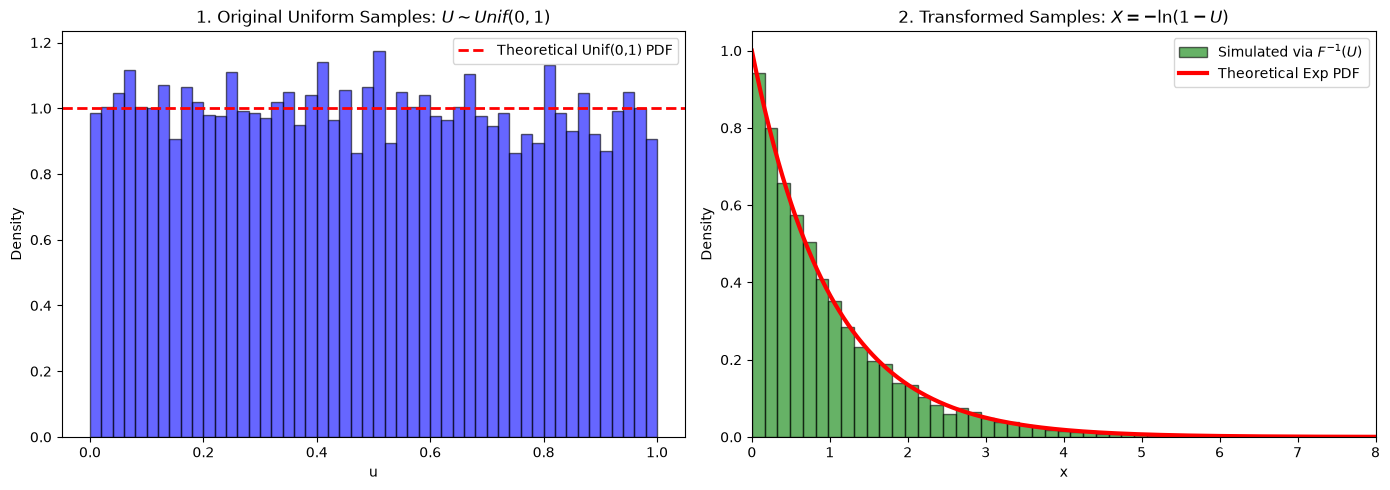

In [1]:
#| label: fig-universality
#| fig-cap: "Passing a uniformly distributed dataset U through the inverse CDF perfectly recreates the target PDF."
#| echo: true
#| warning: false

import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import expon

# Generate 10,000 samples from a Standard Uniform distribution
np.random.seed(42)
U = np.random.uniform(0, 1, 10000)

# Apply Inverse Transform Sampling for Exponential(lambda=1)
X_simulated = -np.log(1 - U)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
plt.style.use('default')

ax1.hist(U, bins=50, color='blue', alpha=0.6, density=True, edgecolor='black')
ax1.axhline(1, color='red', linestyle='dashed', linewidth=2, label='Theoretical Unif(0,1) PDF')
ax1.set_title("1. Original Uniform Samples: $U \sim Unif(0,1)$")
ax1.set_xlabel("u")
ax1.set_ylabel("Density")
ax1.legend()

ax2.hist(X_simulated, bins=50, color='green', alpha=0.6, density=True, edgecolor='black', label='Simulated via $F^{-1}(U)$')
x_axis = np.linspace(0, 8, 1000)
theoretical_pdf = expon.pdf(x_axis, scale=1)
ax2.plot(x_axis, theoretical_pdf, 'r-', lw=3, label='Theoretical Exp PDF')
ax2.set_title("2. Transformed Samples: $X = -\\ln(1-U)$")
ax2.set_xlabel("x")
ax2.set_ylabel("Density")
ax2.set_xlim(0, 8)
ax2.legend()

plt.tight_layout()
plt.show()